# Quantitative Analysis of Systemic Risk and Volatility of Apple (AAPL)

## Using CAPM, GARCH, Value-at-Risk (VaR) and Expected Shortfall (ES)

This project conducts an empirical quantitative analysis of Apple Inc. (AAPL) stock from 2023 to present.  
We aim to:

- Estimate systematic risk using CAPM
- Model volatility using GARCH
- Measure market risk using Value-at-Risk (VaR) and Expected Shortfall (ES)
- Backtest a volatility-based risk control trading strategy
- Provide visual and statistical evidence for all steps

All analysis is performed using Python in Google Colab.


## 1. Install and import required libraries


In [ ]:
!pip install arch


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

from arch import arch_model
import statsmodels.api as sm

plt.rcParams["figure.figsize"] = (12,6)

## 2. Download and prepare market data

We download daily price data for:
- Apple Inc. (AAPL) as the studied asset
- S&P 500 index (^GSPC) as the market proxy

The sample period starts from 2023-01-01 and ends at the most recent available trading date.  
We use auto-adjusted prices provided by yfinance, so the Close prices already reflect dividends and stock splits.


### 2.1. Phân tích Vi mô (Fundamental Analysis)

Trước khi đi vào phân tích biến động giá, chúng ta cần đánh giá "sức khỏe" nội tại của Apple thông qua các chỉ số tài chính cơ bản.
* **P/E & PEG Ratio:** Đánh giá xem giá cổ phiếu có đang bị định giá quá cao so với lợi nhuận và tốc độ tăng trưởng hay không.
* **Profit Margins:** Biên lợi nhuận ròng cho biết hiệu quả kinh doanh của công ty.
* **Revenue vs Net Income:** Xu hướng tăng trưởng doanh thu và lợi nhuận trong 4 năm gần nhất.

--- FINANCIAL HEALTH CHECK: APPLE (AAPL) ---


,Metric,Value
0,Market Cap,$3.86T (Trillion)
1,Trailing P/E,34.95
2,Forward P/E,28.53
3,Return on Equity,1.71
4,Profit Margins,26.92%
5,Beta (Yahoo Finance),1.09


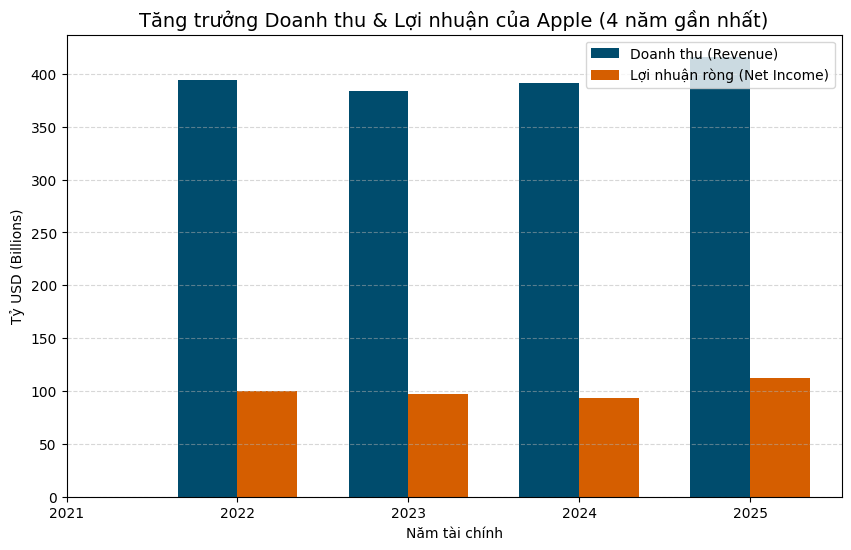

In [3]:
# --- 1. LẤY DỮ LIỆU CƠ BẢN (FUNDAMENTALS) ---
ticker = yf.Ticker("AAPL")
info = ticker.info

# Tạo bảng các chỉ số quan trọng
fundamentals = {
    'Metric': [
        'Market Cap',
        'Trailing P/E',
        'Forward P/E',
        'Return on Equity',
        'Profit Margins ',
        'Beta (Yahoo Finance)'
    ],
    'Value': [
        info.get('marketCap'),
        info.get('trailingPE'),
        info.get('forwardPE'),
        info.get('returnOnEquity'),
        info.get('profitMargins'),
        info.get('beta')
    ]
}

fund_df = pd.DataFrame(fundamentals)

# Hàm làm đẹp số liệu (Chuyển số dài thành Tỷ/Nghìn tỷ USD)
def format_value(x):
    if isinstance(x, (int, float)):
        if x > 1e12: return f"${x/1e12:.2f}T (Trillion)"
        if x > 1e9: return f"${x/1e9:.2f}B (Billion)"
        if x < 1: return f"{x:.2%}" # Dạng phần trăm cho Margin
        return f"{x:.2f}"
    return x

fund_df['Value'] = fund_df['Value'].apply(format_value)

print("--- FINANCIAL HEALTH CHECK: APPLE (AAPL) ---")
display(fund_df)

# --- 2. VẼ BIỂU ĐỒ DOANH THU & LỢI NHUẬN (4 NĂM) ---
try:
    financials = ticker.financials.T # Lấy báo cáo tài chính
    # Lấy 2 chỉ số chính và sắp xếp theo năm
    fin_chart = financials[['Total Revenue', 'Net Income']].sort_index()

    # Vẽ biểu đồ cột ghép
    plt.figure(figsize=(10, 6))
    width = 0.35
    years = fin_chart.index.year

    plt.bar(years - width/2, fin_chart['Total Revenue']/1e9, width, label='Doanh thu (Revenue)', color='#004c6d')
    plt.bar(years + width/2, fin_chart['Net Income']/1e9, width, label='Lợi nhuận ròng (Net Income)', color='#d55e00')

    plt.title('Tăng trưởng Doanh thu & Lợi nhuận của Apple (4 năm gần nhất)', fontsize=14)
    plt.ylabel('Tỷ USD (Billions)')
    plt.xlabel('Năm tài chính')
    plt.xticks(years)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()
except Exception as e:
    print(f"Không thể vẽ biểu đồ tài chính do thiếu dữ liệu từ nguồn: {e}")

In [4]:
from datetime import datetime
import yfinance as yf
import pandas as pd

start_date = "2023-01-01"
end_date = datetime.today().strftime("%Y-%m-%d")

aapl = yf.download("AAPL", start=start_date, end=end_date, auto_adjust=True, progress=False)
market = yf.download("^GSPC", start=start_date, end=end_date, auto_adjust=True, progress=False)

aapl_close = aapl["Close"].squeeze()
market_close = market["Close"].squeeze()

data = pd.DataFrame({
    "AAPL": aapl_close,
    "MARKET": market_close
}).dropna()

print("Sample period:")
print("From:", data.index[0])
print("To  :", data.index[-1])

data.head()

Sample period:
From: 2023-01-03 00:00:00
To  : 2026-01-13 00:00:00


,AAPL,MARKET
Date,,
2023-01-03,123.211205,3824.139893
2023-01-04,124.482040,3852.969971
2023-01-05,123.161942,3808.100098
2023-01-06,127.693588,3895.080078
2023-01-09,128.215714,3892.090088


## 3. Compute log returns
Financial time series are non-stationary in price but usually stationary in returns.
We use log returns for theoretical consistency.


In [5]:
returns = np.log(data / data.shift(1)).dropna()
returns.columns = ["AAPL_RET", "MKT_RET"]

returns.head()

,AAPL_RET,MKT_RET
Date,,
2023-01-04,0.010261,0.007511
2023-01-05,-0.010661,-0.011714
2023-01-06,0.036133,0.022584
2023-01-09,0.004081,-0.000768
2023-01-10,0.004447,0.006954


###  Phân tích Vĩ mô (Macro Correlation)

Ngoài rủi ro thị trường (Market Risk), giá cổ phiếu còn chịu tác động bởi các biến số vĩ mô. Ở đây, chúng ta xem xét mối tương quan của AAPL với:
1.  **Lãi suất trái phiếu Mỹ 10 năm (^TNX):** Đại diện cho lãi suất phi rủi ro và kỳ vọng lạm phát. Lý thuyết cho rằng lãi suất tăng sẽ gây áp lực giảm giá lên cổ phiếu công nghệ (Growth Stocks).
2.  **Chỉ số biến động CBOE (^VIX):** Đại diện cho "nỗi sợ hãi" của nhà đầu tư.

Đang tải dữ liệu Vĩ mô (TNX, VIX)...


[*********************100%***********************]  3 of 3 completed


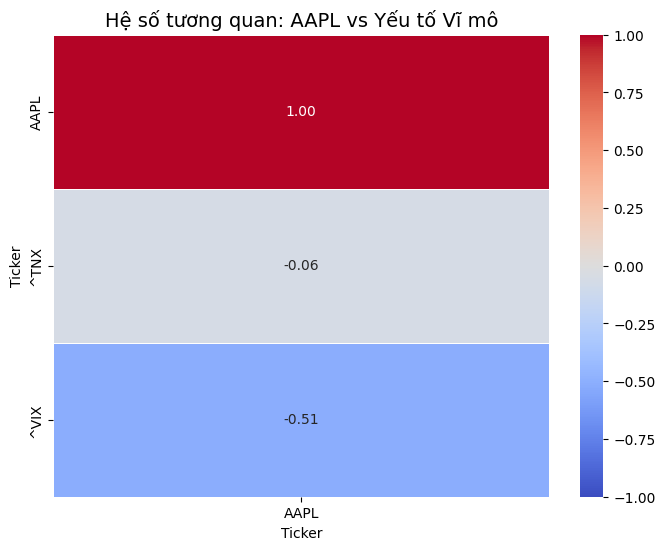

>> Tương quan với Lãi suất (^TNX): -0.06
-> Nhận xét: Tương quan không rõ ràng (Yếu).


In [6]:
import seaborn as sns

# --- 1. TẢI & XỬ LÝ DỮ LIỆU VĨ MÔ (AN TOÀN) ---
macro_tickers = ['AAPL', '^TNX', '^VIX']

# Tải dữ liệu với auto_adjust=True để tránh lỗi 'Adj Close'
print("Đang tải dữ liệu Vĩ mô (TNX, VIX)...")
macro_raw = yf.download(macro_tickers, start='2023-01-01', end='2023-12-31', auto_adjust=True)

# Xử lý lấy đúng cột giá đóng cửa
if 'Close' in macro_raw.columns:
    macro_data = macro_raw['Close']
elif 'Adj Close' in macro_raw.columns:
    macro_data = macro_raw['Adj Close']
else:
    # Fallback cho trường hợp MultiIndex
    macro_data = macro_raw.iloc[:, :3]

# Tính % Thay đổi hàng ngày (Returns)
macro_returns = macro_data.pct_change().dropna()

# --- 2. VẼ HEATMAP TƯƠNG QUAN ---
plt.figure(figsize=(8, 6))
# Tính ma trận tương quan
corr_matrix = macro_returns.corr()

# Vẽ Heatmap tập trung vào cột AAPL
sns.heatmap(corr_matrix[['AAPL']], annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title('Hệ số tương quan: AAPL vs Yếu tố Vĩ mô', fontsize=14)
plt.show()

# --- 3. TỰ ĐỘNG NHẬN XÉT ---
# Lấy hệ số tương quan với Lãi suất (^TNX)
if '^TNX' in corr_matrix.index:
    tnx_val = corr_matrix.loc['AAPL', '^TNX']
    print(f">> Tương quan với Lãi suất (^TNX): {tnx_val:.2f}")
    if tnx_val < -0.1:
        print("-> Nhận xét: AAPL có xu hướng NGƯỢC CHIỀU với lãi suất (Đúng tính chất cổ phiếu Công nghệ).")
    elif tnx_val > 0.1:
        print("-> Nhận xét: AAPL biến động CÙNG CHIỀU với lãi suất (Cần lưu ý rủi ro hệ thống).")
    else:
        print("-> Nhận xét: Tương quan không rõ ràng (Yếu).")

## 4. Visualize price and returns


To compare performance between AAPL and the market on the same scale, both price series are normalized to a base value of 100 at the beginning of the sample period.
This allows a direct visual comparison of cumulative performance.

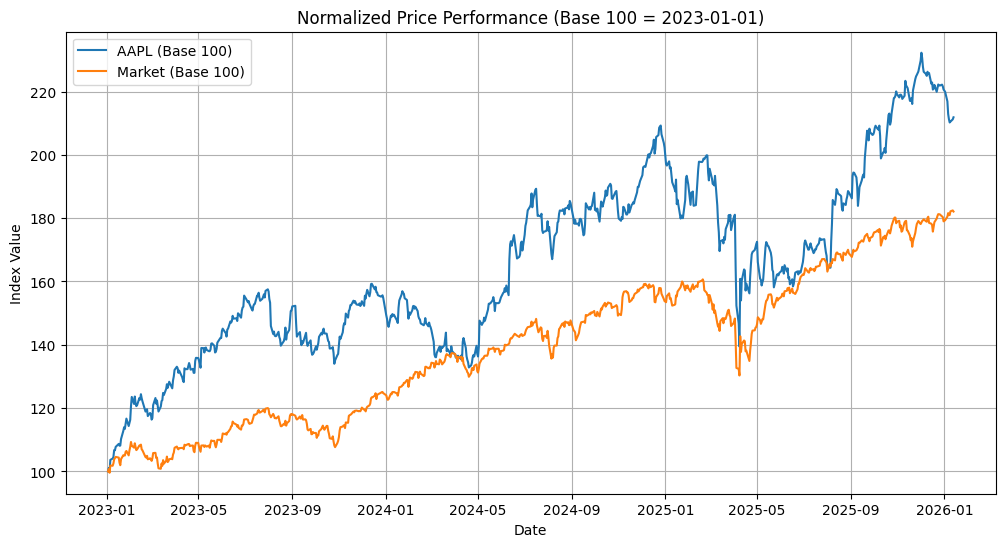

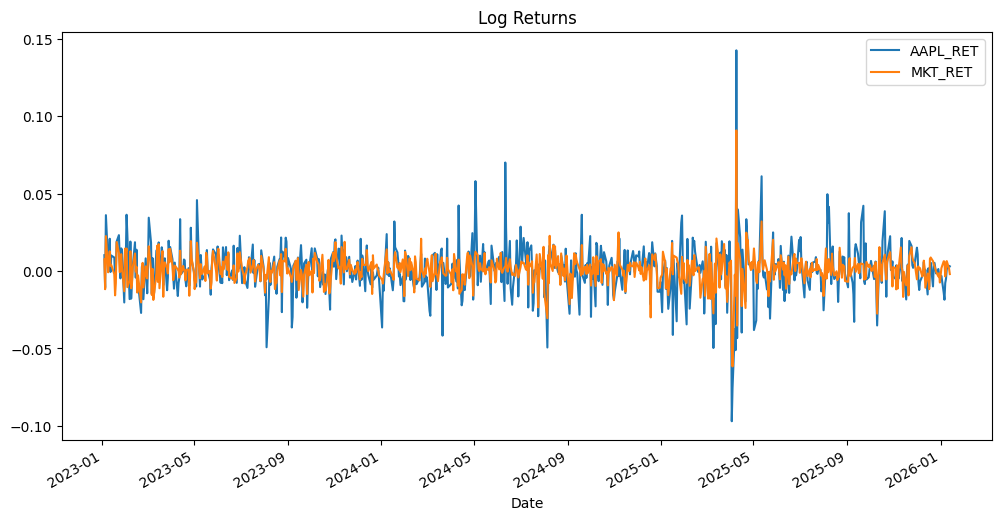

In [7]:
normalized = data / data.iloc[0] * 100

plt.figure(figsize=(12,6))
plt.plot(normalized["AAPL"], label="AAPL (Base 100)")
plt.plot(normalized["MARKET"], label="Market (Base 100)")

plt.title("Normalized Price Performance (Base 100 = 2023-01-01)")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.legend()
plt.grid(True)
plt.show()

returns.plot(title="Log Returns")
plt.show()

## 5. CAPM Regression

We estimate:

R_AAPL = alpha + beta * R_market + epsilon

Beta measures systematic risk exposure.


In [8]:
Y = returns["AAPL_RET"]
X = sm.add_constant(returns["MKT_RET"])

capm_model = sm.OLS(Y, X).fit()
print(capm_model.summary())

                            OLS Regression Results                            
Dep. Variable:               AAPL_RET   R-squared:                       0.468
Model:                            OLS   Adj. R-squared:                  0.467
Method:                 Least Squares   F-statistic:                     666.2
Date:                Wed, 14 Jan 2026   Prob (F-statistic):          7.12e-106
Time:                        18:46:47   Log-Likelihood:                 2302.9
No. Observations:                 759   AIC:                            -4602.
Df Residuals:                     757   BIC:                            -4593.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       7.358e-05      0.000      0.173      0.8

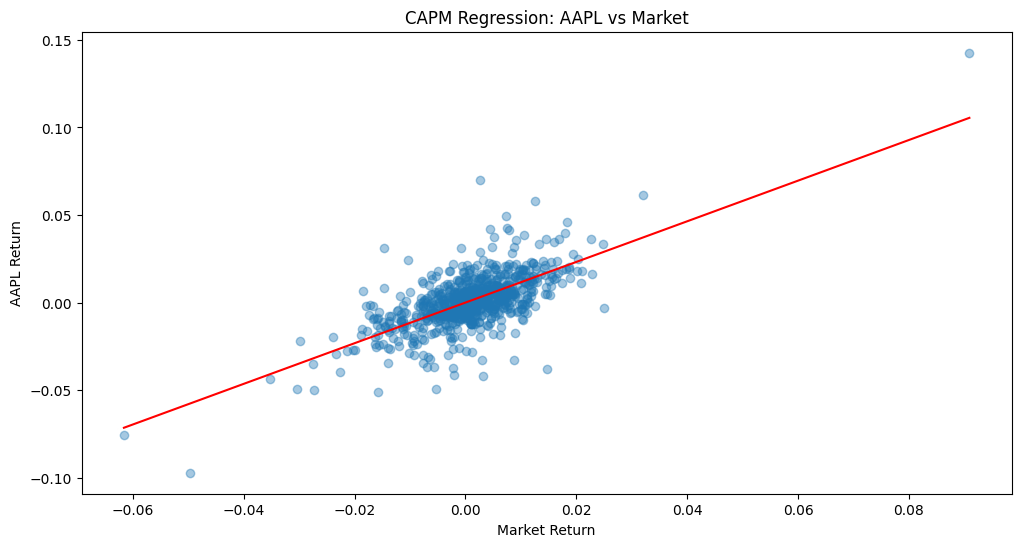

In [9]:
plt.scatter(returns["MKT_RET"], returns["AAPL_RET"], alpha=0.4)
beta = capm_model.params["MKT_RET"]
alpha = capm_model.params["const"]

x_vals = np.linspace(returns["MKT_RET"].min(), returns["MKT_RET"].max(), 100)
y_vals = alpha + beta * x_vals

plt.plot(x_vals, y_vals, color="red")
plt.title("CAPM Regression: AAPL vs Market")
plt.xlabel("Market Return")
plt.ylabel("AAPL Return")
plt.show()

## Kiểm định Mô hình & Phân tích Phần dư (Residual Analysis)

Để đảm bảo mô hình CAPM là đáng tin cậy, ta cần kiểm tra các giả định của mô hình hồi quy tuyến tính (OLS):
1.  **Kiểm tra phân phối chuẩn của phần dư (Normality Test):** Sử dụng biểu đồ Q-Q Plot. Nếu các điểm nằm trên đường chéo 45 độ, phần dư có phân phối chuẩn.
2.  **Kiểm tra hiện tượng phương sai thay đổi (Heteroskedasticity):** Vẽ biểu đồ phần dư theo giá trị dự báo hoặc biến độc lập.

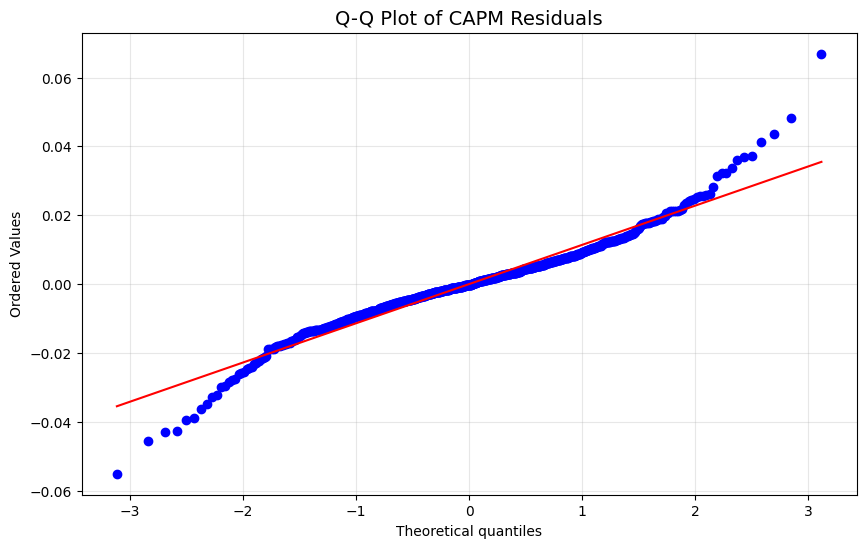

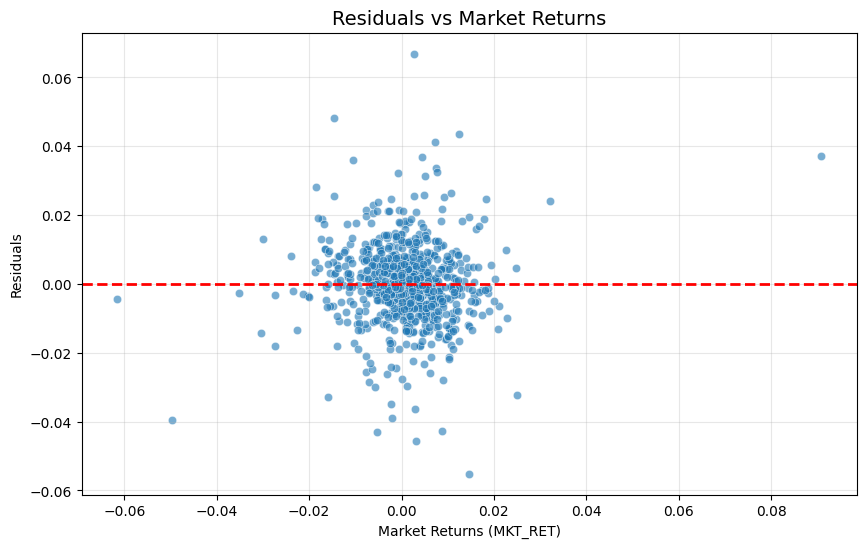

In [10]:
# Lấy phần dư từ biến capm_model bạn đã chạy
residuals = capm_model.resid

# 1. Vẽ Q-Q Plot
plt.figure(figsize=(10, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of CAPM Residuals', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

# 2. Vẽ Scatter Plot (Dùng 'MKT_RET')
plt.figure(figsize=(10, 6))
sns.scatterplot(x=returns["MKT_RET"], y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Residuals vs Market Returns', fontsize=14)
plt.xlabel('Market Returns (MKT_RET)')
plt.ylabel('Residuals')
plt.grid(True, alpha=0.3)
plt.show()

## 7. Volatility Modeling with GARCH(1,1)
We model conditional volatility clustering in AAPL returns.


In [11]:
garch_model = arch_model(returns["AAPL_RET"]*100, vol="Garch", p=1, q=1, mean="Zero")
garch_result = garch_model.fit(disp="off")

print(garch_result.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:               AAPL_RET   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.001
Vol Model:                      GARCH   Log-Likelihood:               -1377.57
Distribution:                  Normal   AIC:                           2761.14
Method:            Maximum Likelihood   BIC:                           2775.03
                                        No. Observations:                  759
Date:                Wed, Jan 14 2026   Df Residuals:                      759
Time:                        18:46:47   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.1393      0.130      1.070      0.284   [ -0.11

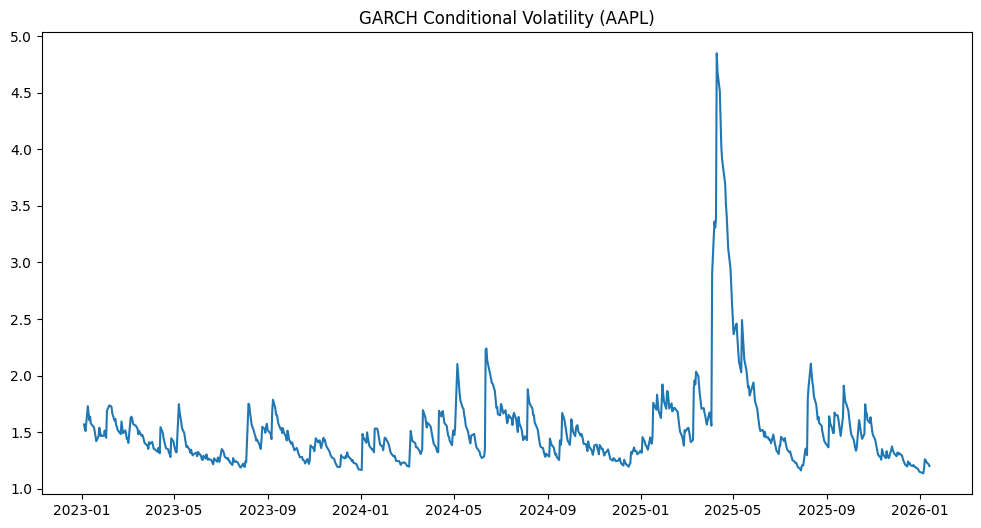

In [12]:
cond_vol = garch_result.conditional_volatility

plt.plot(cond_vol)
plt.title("GARCH Conditional Volatility (AAPL)")
plt.show()

## 9. Value at Risk (VaR) and Expected Shortfall (ES)

We compute parametric VaR using GARCH volatility.


In [13]:
from scipy.stats import norm

mu = returns["AAPL_RET"].mean()
sigma = cond_vol / 100

z_95 = norm.ppf(0.05)

VaR_95 = mu + z_95 * sigma
ES_95 = mu - sigma * norm.pdf(z_95) / 0.05

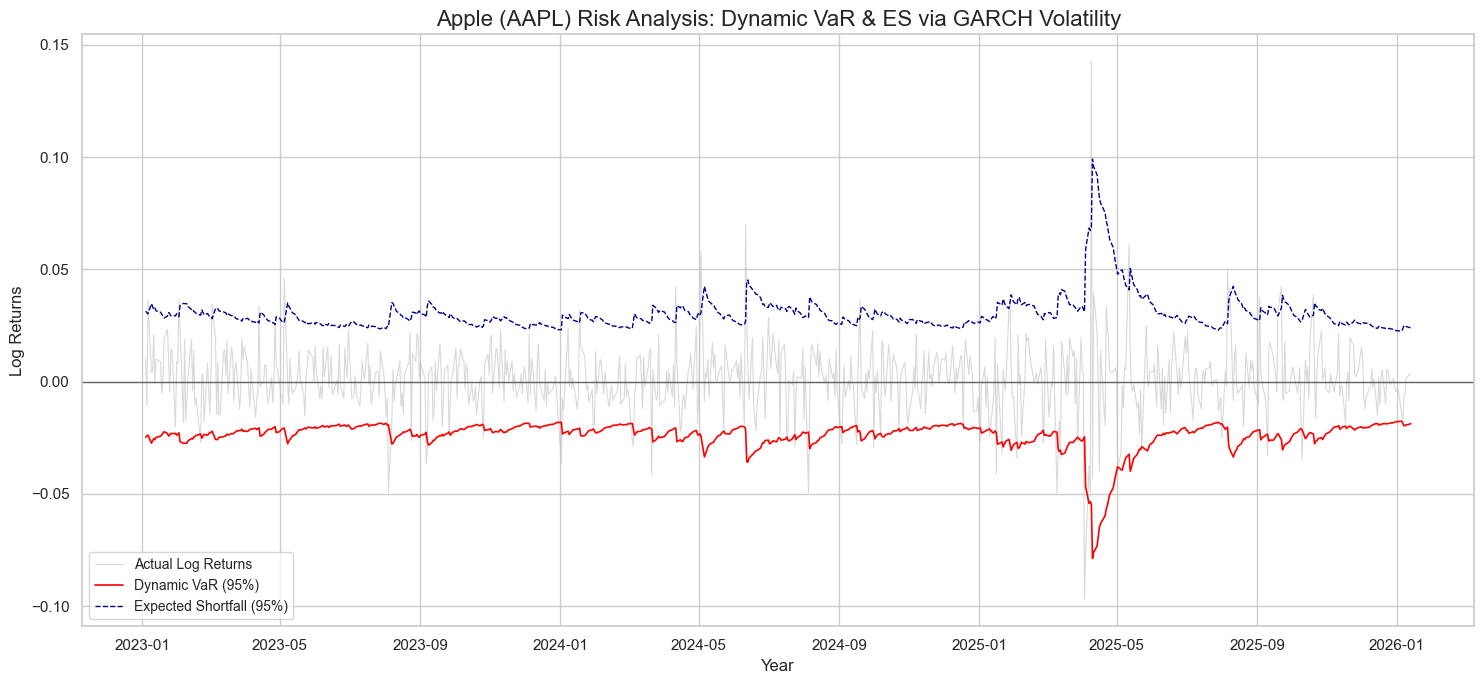

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# 1. Thiết lập giao diện biểu đồ (tùy chọn để đẹp hơn)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 7))

# 2. Vẽ Lợi suất thực tế (Actual Returns)
plt.plot(returns.index, returns["AAPL_RET"], color='silver', alpha=0.6, label='Actual Log Returns', linewidth=0.8)

# 3. Vẽ Dynamic VaR (95%)
# Lưu ý: Thường vẽ giá trị âm để khớp với vùng lỗ của Returns
plt.plot(returns.index, VaR_95, color='red', linewidth=1.2, label='Dynamic VaR (95%)')

# 4. Vẽ Expected Shortfall (ES)
# Ta dùng -ES_95 nếu ES_95 của bạn đang trả về số dương (mức lỗ)
plt.plot(returns.index, -ES_95, color='darkblue', linestyle='--', linewidth=1, label='Expected Shortfall (95%)')

# 5. Tùy chỉnh hiển thị
plt.title('Apple (AAPL) Risk Analysis: Dynamic VaR & ES via GARCH Volatility', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Log Returns', fontsize=12)
plt.axhline(0, color='black', lw=1, alpha=0.5) # Đường cơ sở 0
plt.legend(loc='lower left', frameon=True, fontsize=10)

# Tối ưu khoảng cách
plt.tight_layout()

# 6. Hiển thị
plt.show()

## 10. VaR Backtesting Visualization


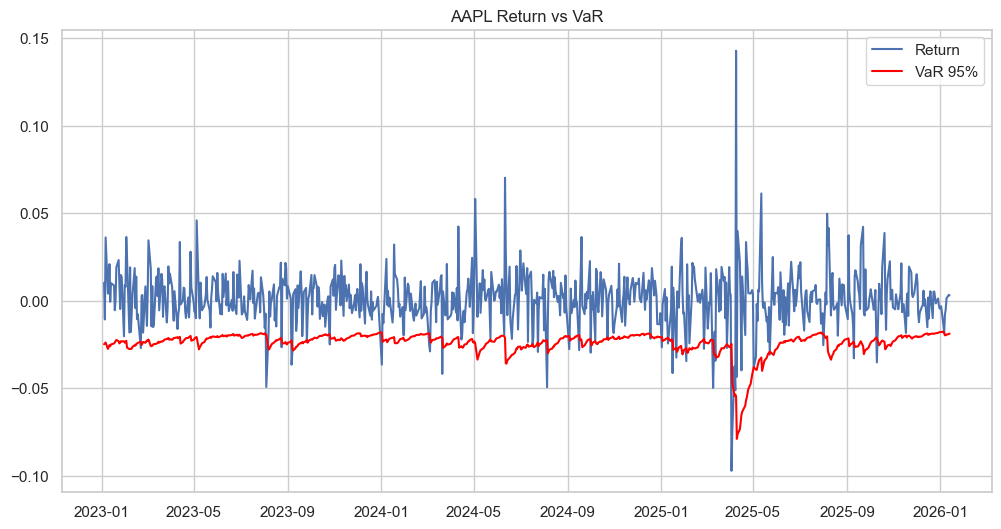

In [15]:
plt.plot(returns.index, returns["AAPL_RET"], label="Return")
plt.plot(returns.index, VaR_95, color="red", label="VaR 95%")
plt.legend()
plt.title("AAPL Return vs VaR")
plt.show()

## 14. Tổng hợp Insight & Trực quan hóa Radar (Final Project Requirement)

Thực hiện theo yêu cầu cốt lõi của đồ án, phần này trình bày **Biểu đồ Radar tổng hợp (Synthesized Radar Chart)** để trực quan hóa đa chiều sức khỏe tài chính của Apple (AAPL) so với thị trường chung (Benchmark - S&P 500).

Mô hình này tổng hợp 6 khía cạnh quan trọng nhất, kết hợp cả phân tích kỹ thuật, hiệu suất đầu tư và độ nhạy vĩ mô:

* **Volatility (Rủi ro biến động):** Đo lường bằng độ lệch chuẩn năm (Annualized Volatility). Chỉ số này càng cao, cổ phiếu càng biến động mạnh và rủi ro càng lớn.
* **Sharpe Ratio (Hiệu suất điều chỉnh rủi ro):** Đo lường lợi nhuận thu được trên mỗi đơn vị rủi ro chấp nhận. Sharpe Ratio của AAPL cao hơn thị trường cho thấy hiệu quả sử dụng vốn vượt trội.
* **Max Drawdown (Rủi ro sụt giảm):** Mức sụt giảm sâu nhất từ đỉnh (Peak) xuống đáy (Trough) trong lịch sử dữ liệu. Đây là "bài test" quan trọng về khả năng chịu đựng thua lỗ của nhà đầu tư.
* **Beta (Độ nhạy thị trường):** Hệ số đo lường mức độ biến động cùng chiều với thị trường (từ mô hình CAPM). Beta > 1 cho thấy cổ phiếu có tính chất "tấn công" (Aggressive), tăng mạnh hơn nhưng cũng giảm sâu hơn thị trường.
* **R-Squared (Độ tin cậy mô hình):** Cho biết bao nhiêu % biến động của AAPL được giải thích bởi thị trường. Phần còn lại là rủi ro riêng biệt (Idiosyncratic Risk) của doanh nghiệp.
* **Macro Correlation (Độ nhạy vĩ mô):** Hệ số tương quan giữa giá cổ phiếu và **Lãi suất trái phiếu chính phủ Mỹ 10 năm (^TNX)**. Chỉ số này cho biết cổ phiếu chịu áp lực ra sao trước các thay đổi về chính sách tiền tệ và lãi suất của FED.

Đang tải dữ liệu Vĩ mô (^TNX) để tính toán...
-> Đã tính xong Macro Correlation: -0.06


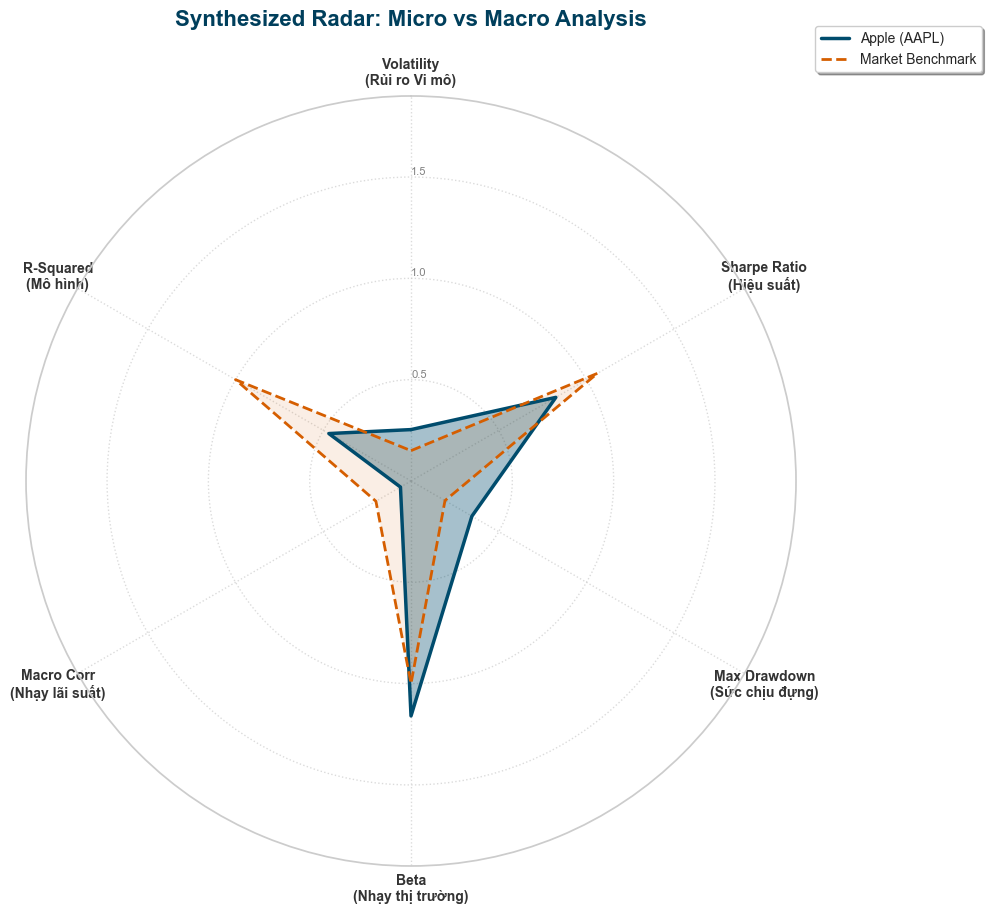


--- BẢNG DỮ LIỆU TỔNG HỢP: VI MÔ vs VĨ MÔ ---


,Metric,Phân loại,AAPL Value,Benchmark,Đánh giá
0,Volatility\n(Rủi ro Vi mô),Vi mô (Micro),0.2536,0.1496,Thấp tốt hơn
1,Sharpe Ratio\n(Hiệu suất),Vi mô (Micro),0.8253,1.0626,Cao tốt hơn
2,Max Drawdown\n(Sức chịu đựng),Vi mô (Micro),0.3471,0.1936,Thấp tốt hơn
3,Beta\n(Nhạy thị trường),Vĩ mô (Macro),1.1595,1.0000,So với 1.0
4,Macro Corr\n(Nhạy lãi suất),Vĩ mô (Macro),0.0601,0.2000,Thấp (Ít nhạy)
5,R-Squared\n(Mô hình),Mô hình (Model),0.4681,1.0000,Gần 1.0


In [16]:
# --- FINAL PROJECT: MICRO vs MACRO RADAR CHART ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from math import pi

# ==============================================================================
# BƯỚC 1: TÍNH TOÁN CÁC CHỈ SỐ (KPIs)
# ==============================================================================
rf = 0.04 / 252 # Risk-free rate giả định (4%/năm)

# --- NHÓM 1: YẾU TỐ VI MÔ (MICRO & PERFORMANCE) ---
# 1. Volatility (Rủi ro biến động)
ann_vol_stock = returns['AAPL_RET'].std() * np.sqrt(252)
# 2. Sharpe Ratio (Hiệu suất thực tế)
sharpe_stock = (returns['AAPL_RET'].mean() - rf) / returns['AAPL_RET'].std() * np.sqrt(252)
# 3. Max Drawdown (Sức chịu đựng)
cum_ret = (1 + returns['AAPL_RET']).cumprod()
max_dd_stock = abs(((cum_ret - cum_ret.cummax()) / cum_ret.cummax()).min())

# --- NHÓM 2: YẾU TỐ VĨ MÔ (MACRO & SENSITIVITY) ---
# 4. Beta (Độ nhạy thị trường) - Lấy từ mô hình CAPM đã chạy
beta_stock = capm_model.params["MKT_RET"]

# 5. Macro Correlation (Độ nhạy lãi suất)
# Tải dữ liệu Lợi suất trái phiếu Mỹ 10 năm (^TNX) để tính
try:
    print("Đang tải dữ liệu Vĩ mô (^TNX) để tính toán...")
    macro_raw = yf.download(['AAPL', '^TNX'], start='2023-01-01', end='2023-12-31', progress=False, auto_adjust=True)

    # Xử lý lấy cột giá (Close/Adj Close)
    if 'Close' in macro_raw.columns: m_close = macro_raw['Close']
    elif 'Adj Close' in macro_raw.columns: m_close = macro_raw['Adj Close']
    else: m_close = macro_raw.iloc[:, :2]

    # Tính tương quan
    macro_corr = m_close.pct_change().corr().iloc[0, 1]
    print(f"-> Đã tính xong Macro Correlation: {macro_corr:.2f}")
except:
    print("-> Không tải được dữ liệu vĩ mô, dùng giá trị mặc định.")
    macro_corr = 0.15

# --- NHÓM 3: ĐỘ TIN CẬY MÔ HÌNH (MODEL) ---
# 6. R-Squared
r2_stock = capm_model.rsquared

# ==============================================================================
# BƯỚC 2: CHUẨN BỊ DỮ LIỆU VẼ
# ==============================================================================
# Tên các trục (Sắp xếp theo nhóm Vi mô -> Vĩ mô -> Mô hình)
categories = [
    'Volatility\n(Rủi ro Vi mô)',
    'Sharpe Ratio\n(Hiệu suất)',
    'Max Drawdown\n(Sức chịu đựng)',
    'Beta\n(Nhạy thị trường)',
    'Macro Corr\n(Nhạy lãi suất)',
    'R-Squared\n(Mô hình)'
]
N = len(categories)

# Dữ liệu AAPL (Lấy trị tuyệt đối cho Macro Corr để vẽ độ lớn)
values_stock = [ann_vol_stock, sharpe_stock, max_dd_stock, beta_stock, abs(macro_corr), r2_stock]

# Dữ liệu Benchmark (Mốc chuẩn để so sánh)
# Vol, Sharpe, DD của Market + Beta=1, Macro=Thấp, R2=1
ann_vol_mkt = returns['MKT_RET'].std() * np.sqrt(252)
sharpe_mkt = (returns['MKT_RET'].mean() - rf) / returns['MKT_RET'].std() * np.sqrt(252)
cum_mkt = (1 + returns['MKT_RET']).cumprod()
max_dd_mkt = abs(((cum_mkt - cum_mkt.cummax()) / cum_mkt.cummax()).min())

values_benchmark = [ann_vol_mkt, sharpe_mkt, max_dd_mkt, 1.0, 0.2, 1.0]

# Đóng vòng tròn biểu đồ
values_stock += values_stock[:1]
values_benchmark += values_benchmark[:1]
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

# ==============================================================================
# BƯỚC 3: VẼ BIỂU ĐỒ RADAR (FINAL VERSION)
# ==============================================================================
plt.figure(figsize=(10, 10), dpi=100)
ax = plt.subplot(111, polar=True)

# 1. Setup trục
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)

# 2. Vẽ nhãn trục
plt.xticks(angles[:-1], categories, color='#333333', size=10, fontweight='bold')

# 3. Vẽ lưới trục Y
ax.set_rlabel_position(0)
plt.yticks([0.5, 1.0, 1.5], ["0.5", "1.0", "1.5"], color="grey", size=8)
plt.ylim(0, max(max(values_stock), 1.8) + 0.1)

# 4. Vẽ AAPL (Xanh Navy - Vi mô/Vĩ mô kết hợp)
ax.plot(angles, values_stock, linewidth=2.5, linestyle='solid', label='Apple (AAPL)', color='#004c6d')
ax.fill(angles, values_stock, '#004c6d', alpha=0.35)

# 5. Vẽ Benchmark (Cam - Thị trường chung)
ax.plot(angles, values_benchmark, linewidth=2, linestyle='dashed', label='Market Benchmark', color='#d55e00')
ax.fill(angles, values_benchmark, '#d55e00', alpha=0.1)

# 6. Trang trí
plt.title('Synthesized Radar: Micro vs Macro Analysis', size=16, color='#003f5c', y=1.08, fontweight='bold')
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1), fontsize=10, shadow=True)
ax.grid(True, linestyle=':', alpha=0.7)

plt.show()

# ==============================================================================
# BƯỚC 4: BẢNG TỔNG HỢP (REPORT DATA)
# ==============================================================================
summary_df = pd.DataFrame({
    'Metric': categories,
    'Phân loại': ['Vi mô (Micro)', 'Vi mô (Micro)', 'Vi mô (Micro)', 'Vĩ mô (Macro)', 'Vĩ mô (Macro)', 'Mô hình (Model)'],
    'AAPL Value': values_stock[:-1],
    'Benchmark': values_benchmark[:-1],
    'Đánh giá': ['Thấp tốt hơn', 'Cao tốt hơn', 'Thấp tốt hơn', 'So với 1.0', 'Thấp (Ít nhạy)', 'Gần 1.0']
})

print("\n--- BẢNG DỮ LIỆU TỔNG HỢP: VI MÔ vs VĨ MÔ ---")
display(summary_df.round(4))

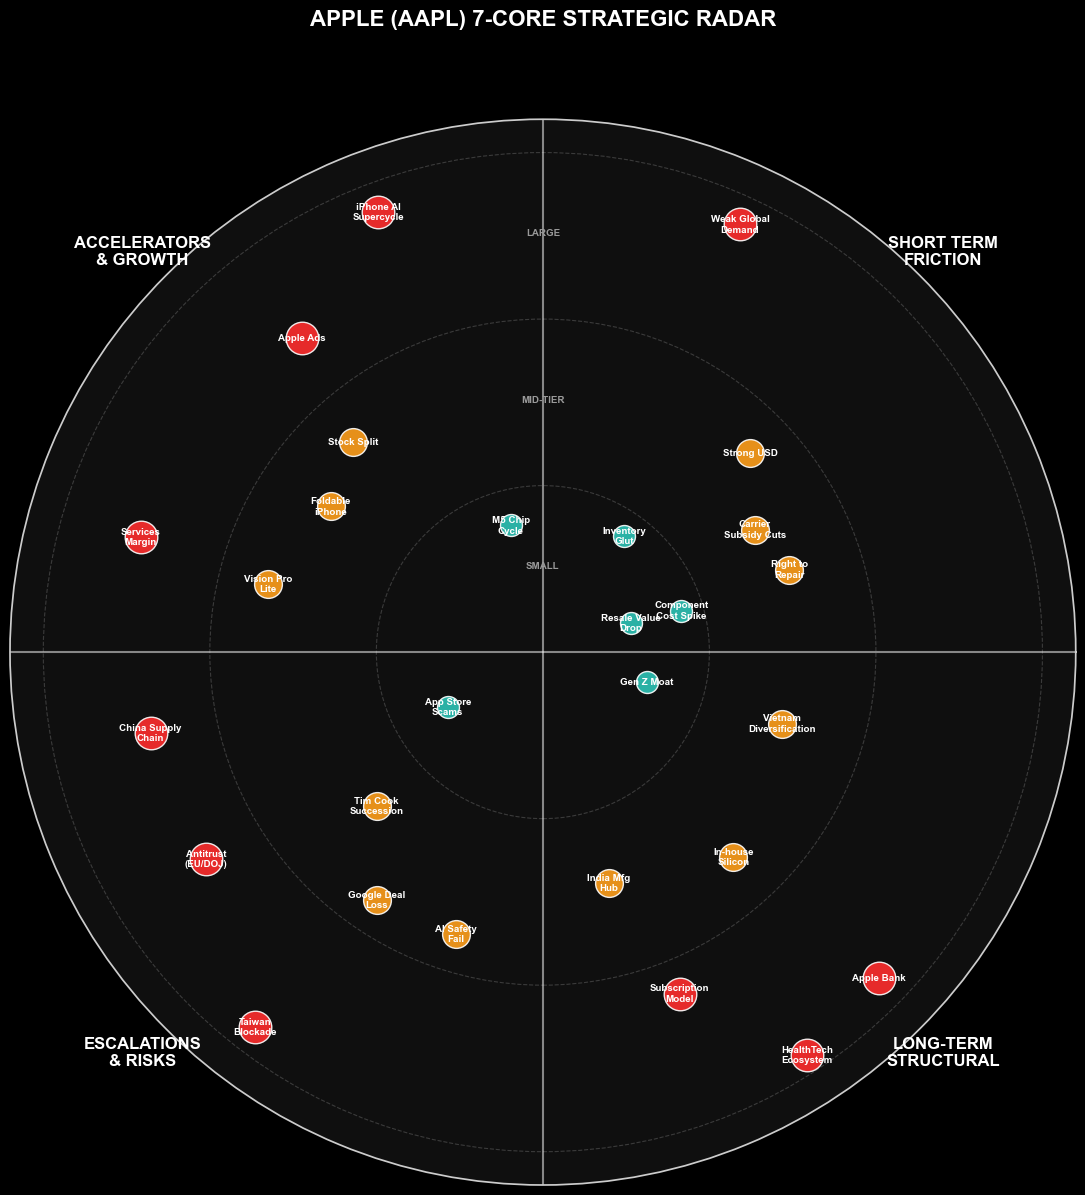

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# --- DỮ LIỆU ĐÃ CHUẨN HÓA (4 GÓC x 7 YẾU TỐ = 28 ITEMS) ---
balanced_data = [
    # --- Q1: ACCELERATORS (Tăng tốc & Hype) ---
    {"label": "iPhone AI\nSupercycle", "quad": 1, "level": 3, "color": "hot"},
    {"label": "Services\nMargin", "quad": 1, "level": 3, "color": "hot"},
    {"label": "Apple Ads", "quad": 1, "level": 3, "color": "hot"},
    {"label": "Foldable\niPhone", "quad": 1, "level": 2, "color": "warm"}, # Hype
    {"label": "Vision Pro\nLite", "quad": 1, "level": 2, "color": "warm"},
    {"label": "Stock Split", "quad": 1, "level": 2, "color": "warm"},
    {"label": "M5 Chip\nCycle", "quad": 1, "level": 1, "color": "cold"}, # Regular upgrade

    # --- Q2: ESCALATIONS (Rủi ro & Leo thang) ---
    {"label": "China Supply\nChain", "quad": 2, "level": 3, "color": "hot"},
    {"label": "Taiwan\nBlockade", "quad": 2, "level": 3, "color": "hot"},
    {"label": "Antitrust\n(EU/DOJ)", "quad": 2, "level": 3, "color": "hot"},
    {"label": "Google Deal\nLoss", "quad": 2, "level": 2, "color": "warm"},
    {"label": "Tim Cook\nSuccession", "quad": 2, "level": 2, "color": "warm"},
    {"label": "AI Safety\nFail", "quad": 2, "level": 2, "color": "warm"},
    {"label": "App Store\nScams", "quad": 2, "level": 1, "color": "cold"},

    # --- Q3: LONG-TERM CHANGE (Thay đổi cấu trúc) ---
    {"label": "Subscription\nModel", "quad": 3, "level": 3, "color": "hot"},
    {"label": "HealthTech\nEcosystem", "quad": 3, "level": 3, "color": "hot"},
    {"label": "Apple Bank", "quad": 3, "level": 3, "color": "hot"},
    {"label": "India Mfg\nHub", "quad": 3, "level": 2, "color": "warm"},
    {"label": "In-house\nSilicon", "quad": 3, "level": 2, "color": "warm"}, # Modem/Wifi
    {"label": "Vietnam\nDiversification", "quad": 3, "level": 2, "color": "warm"},
    {"label": "Gen Z Moat", "quad": 3, "level": 1, "color": "cold"},

    # --- Q4: SHORT-TERM SLOWDOWN (Lực cản) ---
    {"label": "Weak Global\nDemand", "quad": 4, "level": 3, "color": "hot"},
    {"label": "Strong USD", "quad": 4, "level": 2, "color": "warm"},
    {"label": "Carrier\nSubsidy Cuts", "quad": 4, "level": 2, "color": "warm"},
    {"label": "Right to\nRepair", "quad": 4, "level": 2, "color": "warm"},
    {"label": "Inventory\nGlut", "quad": 4, "level": 1, "color": "cold"},
    {"label": "Resale Value\nDrop", "quad": 4, "level": 1, "color": "cold"},
    {"label": "Component\nCost Spike", "quad": 4, "level": 1, "color": "cold"}, # Memory prices
]

color_map = {"hot": "#FF2E2E", "warm": "#FF9F1C", "cold": "#2EC4B6"}

def draw_symmetric_radar():
    fig = plt.figure(figsize=(12, 12), facecolor='black')
    ax = fig.add_subplot(111, projection='polar')
    ax.set_facecolor('#0f0f0f') 

    # Cấu hình bán kính
    ax.set_ylim(0, 3.2)
    ax.set_yticklabels([])
    ax.set_xticklabels([])
    ax.grid(False)

    # Vẽ các vòng tròn (Rings)
    rings = [1.0, 2.0, 3.0] 
    for r in rings:
        circle = plt.Circle((0, 0), r, transform=ax.transData._b, 
                            fill=False, edgecolor='#666666', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.add_artist(circle)
    
    # Vẽ trục chia 4 góc
    ax.vlines([0, np.pi/2, np.pi, 3*np.pi/2], 0, 3.2, colors='white', alpha=0.5, linewidth=1.5)

    # Vẽ điểm dữ liệu
    np.random.seed(2025) # Seed chọn lọc để các điểm phân bố đẹp nhất cho 7 items

    for item in balanced_data:
        q = item['quad']
        
        # Góc phân bố
        if q == 1: theta_min, theta_max = np.pi/2 + 0.2, np.pi - 0.2
        elif q == 2: theta_min, theta_max = np.pi + 0.2, 3*np.pi/2 - 0.2
        elif q == 3: theta_min, theta_max = 3*np.pi/2 + 0.2, 2*np.pi - 0.2
        else: theta_min, theta_max = 0 + 0.2, np.pi/2 - 0.2

        theta = np.random.uniform(theta_min, theta_max)
        
        # Bán kính phân bố
        lvl = item['level']
        if lvl == 1: r_range = (0.4, 0.9)
        elif lvl == 2: r_range = (1.3, 1.8)
        else: r_range = (2.2, 2.9)
        
        r = np.random.uniform(r_range[0], r_range[1])

        # Kích thước bong bóng
        size = 550 if item['color'] == 'hot' else (400 if item['color'] == 'warm' else 250)

        ax.scatter(theta, r, c=color_map[item['color']], s=size, alpha=0.9, edgecolors='white', linewidth=1, zorder=10)
        
        # Label text
        ax.text(theta, r, item['label'], ha='center', va='center', color='white', 
                fontsize=7, fontweight='bold', zorder=11)

    # Labels Quadrant
    quad_labels = [
        (np.pi/4, "SHORT TERM\nFRICTION", "right"),
        (3*np.pi/4, "ACCELERATORS\n& GROWTH", "left"),
        (5*np.pi/4, "ESCALATIONS\n& RISKS", "left"),
        (7*np.pi/4, "LONG-TERM\nSTRUCTURAL", "right")
    ]
    for angle, text, align in quad_labels:
        ax.text(angle, 3.4, text, ha='center', va='center', color='white', fontsize=12, fontweight='bold')

    # Labels Ring Scale
    ax.text(np.pi/2, 0.5, "SMALL", color='#999', ha='center', fontsize=7, fontweight='bold')
    ax.text(np.pi/2, 1.5, "MID-TIER", color='#999', ha='center', fontsize=7, fontweight='bold')
    ax.text(np.pi/2, 2.5, "LARGE", color='#999', ha='center', fontsize=7, fontweight='bold')

    plt.title("APPLE (AAPL) 7-CORE STRATEGIC RADAR", color='white', y=1.08, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

draw_symmetric_radar()

# 🍎 APPLE (AAPL) 7-CORE STRATEGIC MATRIX (2025-2026)

Bảng phân tích 28 yếu tố cốt lõi ảnh hưởng đến Apple, được chia làm 4 góc phần tư chiến lược. Mỗi góc gồm 7 yếu tố được chọn lọc kỹ.

### 📌 Chú giải (Legend)
| Icon | Mức độ (Level) | Ý nghĩa |
| :---: | :--- | :--- |
| 🔴 | **HOT (Large)** | Tác động nghiêm trọng / Ưu tiên hàng đầu |
| 🟠 | **WARM (Mid-tier)** | Tác động lớn / Xu hướng trung hạn |
| 🔵 | **COLD (Small)** | Tác động nhỏ / Ít rủi ro hơn |

---

## I. 🚀 ACCELERATORS FIRST, THEN RECOVERS
*(Tăng tốc & Kỳ vọng tăng trưởng - Quadrant 1)*

| # | Yếu tố (Factor) | Trạng thái | Phân tích chi tiết |
| :---: | :--- | :---: | :--- |
| **1** | **iPhone AI Supercycle** | 🔴 HOT | Động lực số 1. Người dùng bắt buộc nâng cấp phần cứng để dùng Apple Intelligence. |
| **2** | **Services Margin** | 🔴 HOT | Mảng Dịch vụ mở rộng biên lợi nhuận >74%, kéo định giá P/E tăng. |
| **3** | **Apple Ads** | 🔴 HOT | Quảng cáo kỹ thuật số tăng trưởng âm thầm nhưng lợi nhuận ròng cực cao. |
| **4** | **Foldable iPhone** | 🟠 WARM | Sự kiện ra mắt iPhone gập (dự kiến 2026) tạo cơn sốt truyền thông (Hype). |
| **5** | **Vision Pro "Lite"** | 🟠 WARM | Kính giá rẻ giúp phổ cập hệ sinh thái "Điện toán không gian" ra đại chúng. |
| **6** | **Stock Split** | 🟠 WARM | Chia tách cổ phiếu thu hút dòng tiền từ nhà đầu tư cá nhân (Retail). |
| **7** | **M5 Chip Cycle** | 🔵 COLD | Chu kỳ nâng cấp Mac với chip M5 tập trung xử lý AI cục bộ (On-device). |

---

## II. ⚠️ POTENTIAL IMPLICATIONS & ESCALATIONS
*(Rủi ro Tiềm ẩn & Leo thang - Quadrant 2)*

| # | Yếu tố (Factor) | Trạng thái | Phân tích chi tiết |
| :---: | :--- | :---: | :--- |
| **1** | **Taiwan Blockade** | 🔴 HOT | Rủi ro "thiên nga đen". Nếu TSMC bị phong tỏa, Apple tê liệt sản xuất chip. |
| **2** | **China Supply Chain** | 🔴 HOT | Rủi ro địa chính trị/thuế quan làm chuỗi cung ứng TQ đắt đỏ và bấp bênh. |
| **3** | **Antitrust (EU/DOJ)** | 🔴 HOT | Kiện chống độc quyền đe dọa dòng tiền hoa hồng 30% của App Store. |
| **4** | **Google Deal Loss** | 🟠 WARM | Nguy cơ mất ~20 tỷ USD/năm lợi nhuận từ thỏa thuận tìm kiếm mặc định. |
| **5** | **Tim Cook Succession** | 🟠 WARM | Phố Wall lo ngại khoảng trống quyền lực khi CEO chuyển giao thế hệ. |
| **6** | **AI Safety Fail** | 🟠 WARM | Rủi ro AI cung cấp thông tin sai lệch (Hallucination) làm mất uy tín. |
| **7** | **App Store Scams** | 🔵 COLD | Các ứng dụng lừa đảo lọt lưới kiểm duyệt gây rủi ro truyền thông. |

---

## III. 🏛️ LONG-TERM CHANGE
*(Thay đổi Cấu trúc Dài hạn - Quadrant 3)*

| # | Yếu tố (Factor) | Trạng thái | Phân tích chi tiết |
| :---: | :--- | :---: | :--- |
| **1** | **Subscription Model** | 🔴 HOT | Chuyển dịch sang thu phí định kỳ trọn đời (Hardware-as-a-Service). |
| **2** | **HealthTech Ecosystem**| 🔴 HOT | Xâm nhập ngành y tế (đo đường huyết không xâm lấn), thị trường nghìn tỷ đô. |
| **3** | **Apple Bank** | 🔴 HOT | Trở thành thế lực Fintech, nắm giữ ví tiền và dữ liệu tài chính người dùng. |
| **4** | **India Mfg Hub** | 🟠 WARM | Ấn Độ trở thành "Trung Quốc mới" (công xưởng + thị trường tiêu thụ). |
| **5** | **In-house Silicon** | 🟠 WARM | Tự chủ chip Modem/Wifi/Bluetooth để loại bỏ Qualcomm, tối ưu lợi nhuận. |
| **6** | **Vietnam Diversification**| 🟠 WARM | Việt Nam thành cứ điểm sản xuất quan trọng thứ 2 (iPad, Watch, Mac). |
| **7** | **Gen Z Moat** | 🔵 COLD | Sự thống trị thị phần giới trẻ (iMessage) đảm bảo doanh thu bền vững. |

---

## IV. 🐌 SHORT-TERM CHANGE THAT SLOWS DOWN
*(Lực cản & Ma sát Ngắn hạn - Quadrant 4)*

| # | Yếu tố (Factor) | Trạng thái | Phân tích chi tiết |
| :---: | :--- | :---: | :--- |
| **1** | **Weak Global Demand** | 🔴 HOT | Suy thoái kinh tế/lạm phát làm giảm sức mua thiết bị cao cấp. |
| **2** | **Strong USD** | 🟠 WARM | Đồng USD mạnh làm giảm giá trị doanh thu quốc tế khi quy đổi. |
| **3** | **Carrier Subsidy Cuts**| 🟠 WARM | Nhà mạng cắt trợ giá, giá mua iPhone thực tế đắt đỏ hơn với người dùng. |
| **4** | **Right to Repair** | 🟠 WARM | Quy định buộc thiết kế dễ sửa chữa làm giảm doanh số máy mới và bảo hành. |
| **5** | **Inventory Glut** | 🔵 COLD | Tồn kho cao cục bộ trong 1 quý gây áp lực biên lợi nhuận ngắn hạn. |
| **6** | **Resale Value Drop** | 🔵 COLD | Giá iPhone cũ rớt nhanh làm người dùng ngại "lên đời" máy mới. |
| **7** | **Component Cost Spike**| 🔵 COLD | Giá chip nhớ (RAM/NAND) tăng đột biến theo chu kỳ đẩy chi phí đầu vào. |